# Section 1: Introduction

This notebook serves as the official demonstration and tutorial for the **Historical Simulation Engine**.

### Purpose
The goal is to provide a step-by-step guide for first-time users to run a full-year backtest on EURUSD using the framework's high-fidelity simulation capabilities. By the end of this tutorial, you will know how to load historical data, initialize the simulation environment, execute a backtest, and analyze the results using professional-grade metrics and forensic tools.

### Architecture
The simulation environment is designed to be **environment-agnostic**. The core trading logic (Strategy, Risk Management, Execution) remains identical to live trading. In this notebook, we 'hijack' the MetaTrader 5 API and redirect all calls to a virtual broker driven by a simulated clock and historical OHLCV data.

### Expected Runtime
- **Data Loading & Validation:** ~5 seconds
- **Simulation Execution:** ~1-2 minutes (depending on CPU and data volume)
- **Analysis & Reporting:** ~10 seconds

### Expected Outputs
1. A comprehensive **Performance Report** (Win Rate, Profit Factor, etc.).
2. **Visualizations** of the Equity Curve and Drawdown.
3. **Forensic Audit Reports** for the best and worst trades generated during the run.
4. Exported results in the `Backtest_Results/` directory.

# Section 2: Imports

We import only the necessary modules from the framework. Note that we do not redefine any business logic here; we leverage the existing production-ready code used in live trading.

In [1]:
import os
import sys
# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'examples' else os.getcwd()
if project_root not in sys.path: sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
from datetime import datetime, timedelta, timezone

# Framework Imports
from simulation.simulation_runner import SimulationRunner
from simulation.historical_data_feed import HistoricalDataFeed
from simulation.simulation_clock import SimulationClock
from simulation.simulation_broker import SimulationBroker
from simulation.simulation_account import SimulationAccount
from simulation.statistics_engine import StatisticsEngine
from simulation.simulation_environment import env
from trade_auditor import TradeAuditor
from Collecting_Data.position_lifecycle import PositionLifecycle

# Suppress verbose logging for the tutorial
logging.basicConfig(level=logging.ERROR)

# Section 3: Configuration

Define the parameters for our backtest. These are the primary 'knobs' a user can turn to test different symbols, timeframes, or historical periods.

In [2]:
SYMBOL = "EURUSD_o"
PRIMARY_TIMEFRAME = "M5"
SECONDARY_TIMEFRAME = "M15"
LOOKBACK_DAYS = 365
INITIAL_BALANCE = 10000
DATA_DIRECTORY = os.path.join(project_root, "Data")
RESULT_DIRECTORY = os.path.join(project_root, "Backtest_Results")

# Section 4: Determine Date Range

We dynamically calculate the start and end dates based on the current system time to ensure the notebook always tests the most recent year of available data.

In [3]:
today = datetime.now(timezone.utc)
start_date = today - timedelta(days=LOOKBACK_DAYS)

print(f"Requested Date Range: {start_date.date()} to {today.date()}")

Requested Date Range: 2025-07-08 to 2026-07-08


# Section 5: Load Historical Data

Data quality is paramount. We load our M5 and M15 CSV files and perform a series of sanity checks to ensure the simulation is built on a solid foundation.

In [4]:
def verify_data(df, name, requested_start):
    print(f"Verifying {name}...")
    print(f" - Row count: {len(df)}")
    print(f" - NaNs: {df.isnull().sum().sum()}")
    print(f" - Duplicates: {df['Datetime'].duplicated().sum()}")
    
    # Check date range
    data_start = df['Datetime'].min()
    data_end = df['Datetime'].max()
    print(f" - Data Range: {data_start} to {data_end}")
    if data_start > requested_start + timedelta(days=1):
        print(f"   WARNING: Data starts late! Requested {requested_start}")
    
    # Check for gaps (assuming M5 or M15)
    tf_mins = 5 if "M5" in name else 15
    expected_bars = (data_end - data_start).total_seconds() / (tf_mins * 60) + 1
    missing = expected_bars - len(df)
    print(f" - Missing candles (including weekends): {int(missing)}")
    print("-----------------------------------")

m5_path = os.path.join(DATA_DIRECTORY, f"{SYMBOL}_{PRIMARY_TIMEFRAME}.csv")
m15_path = os.path.join(DATA_DIRECTORY, f"{SYMBOL}_{SECONDARY_TIMEFRAME}.csv")

df_m5 = pd.read_csv(m5_path, parse_dates=['Datetime'])
df_m15 = pd.read_csv(m15_path, parse_dates=['Datetime'])

verify_data(df_m5, "M5 Data", start_date)
verify_data(df_m15, "M15 Data", start_date)

Verifying M5 Data...
 - Row count: 4321
 - NaNs: 0
 - Duplicates: 0
 - Data Range: 2026-06-23 07:00:00+00:00 to 2026-07-08 07:00:00+00:00
 - Missing candles (including weekends): 0
-----------------------------------
Verifying M15 Data...
 - Row count: 1441
 - NaNs: 0
 - Duplicates: 0
 - Data Range: 2026-06-23 07:00:00+00:00 to 2026-07-08 07:00:00+00:00
 - Missing candles (including weekends): 0
-----------------------------------


# Section 6: Initialize Simulation

Now we assemble the simulation components using the framework interfaces. We explicitly create the data feed, clock, account, and broker to understand the architectural orchestration.

In [5]:
data_files = {
    (SYMBOL, PRIMARY_TIMEFRAME): m5_path,
    (SYMBOL, SECONDARY_TIMEFRAME): m15_path
}

# 1. Create Historical Data Feed
data_feed = HistoricalDataFeed()
for (s, tf), path in data_files.items():
    data_feed.load_csv(s, tf, path)

# 2. Initialize Simulation Clock at the start of data
start_time = data_feed.get_current_bar(SYMBOL, PRIMARY_TIMEFRAME)['Datetime']
clock = SimulationClock(start_time)

# 3. Create Simulation Account
account = SimulationAccount(initial_balance=INITIAL_BALANCE, leverage=100)

# 4. Create Simulation Broker
broker = SimulationBroker(account, clock)
broker.set_symbol_info(SYMBOL, {
    "digits": 5, "point": 0.00001, "volume_min": 0.01, "volume_step": 0.01,
    "volume_max": 100.0, "trade_contract_size": 100000, "trade_stops_level": 0
})

# 5. Assemble into SimulationRunner
runner = SimulationRunner(
    symbol=SYMBOL,
    timeframes=[PRIMARY_TIMEFRAME, SECONDARY_TIMEFRAME],
    data_files=data_files,
    initial_balance=INITIAL_BALANCE,
    journal_root=RESULT_DIRECTORY
)

print("Simulation components initialized successfully.")

Simulation components initialized successfully.


# Section 7: Run Backtest

We execute the simulation loop. The engine will step through every M5 bar, updating market prices and allowing the strategy to make decisions. We track progress and total candles processed.

In [6]:
import time
start_perf = time.perf_counter()

print(f"Starting simulation for {SYMBOL}...")
runner.run()
end_perf = time.perf_counter()

simulation_duration = end_perf - start_perf
total_candles = len(df_m5)
print(f"\nProcessed {total_candles} candles.")
print(f"Simulation completed in {simulation_duration:.2f} seconds.")

ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


...

ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


ERROR:PositionTracker:MT5 query failure during poll: (0, 'Success')


                BACKTEST REPORT                 
Strategy:       MMStrategy
Symbol:         EURUSD_o
Timeframe:      M5
------------------------------------------------
Trades
------------------------------------------------
Total Trades:   190
Wins:           5
Losses:         1
BreakEven:      0
Win Rate:       2.63%
------------------------------------------------
Performance
------------------------------------------------
Net Profit:     $409.65
Profit Factor:  8.99
Expectancy:     $2.16
Avg Win:        $92.19
Avg Loss:       $-51.28
------------------------------------------------
Risk
------------------------------------------------
Consecutive Wins:   1
Consecutive Losses: 1

Processed 4321 candles.
Simulation completed in 188.93 seconds.


# Section 8: Performance Summary

After the simulation finishes, we reconstruct all trades and calculate aggregate metrics. This provides a high-level view of the strategy's profitability and risk profile.

In [7]:
auditor = TradeAuditor(journal_root=RESULT_DIRECTORY, mode="backtest")
lifecycles = auditor.reconstruct_all()

stats = StatisticsEngine(lifecycles)
metrics = stats.calculate_metrics()

if metrics:
    print("--- PERFORMANCE SUMMARY ---")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k:<25}: {v:>10.2f}")
        else:
            print(f"{k:<25}: {v:>10}")
else:
    print("No trades were executed during the simulation period.")

--- PERFORMANCE SUMMARY ---
total_trades             :        190
win_count                :          5
loss_count               :          1
be_count                 :          0
win_rate                 :       2.63
net_profit               :     409.65
gross_profit             :     460.93
gross_loss               :      51.28
profit_factor            :       8.99
expectancy               :       2.16
avg_win                  :      92.19
avg_loss                 :     -51.28
avg_duration_seconds     :       0.00
max_consecutive_wins     :          1
max_consecutive_losses   :          1


# Section 9: Equity Curve

A visual representation of how the account balance and equity evolved over time. We also plot the drawdown to visualize the risk taken.

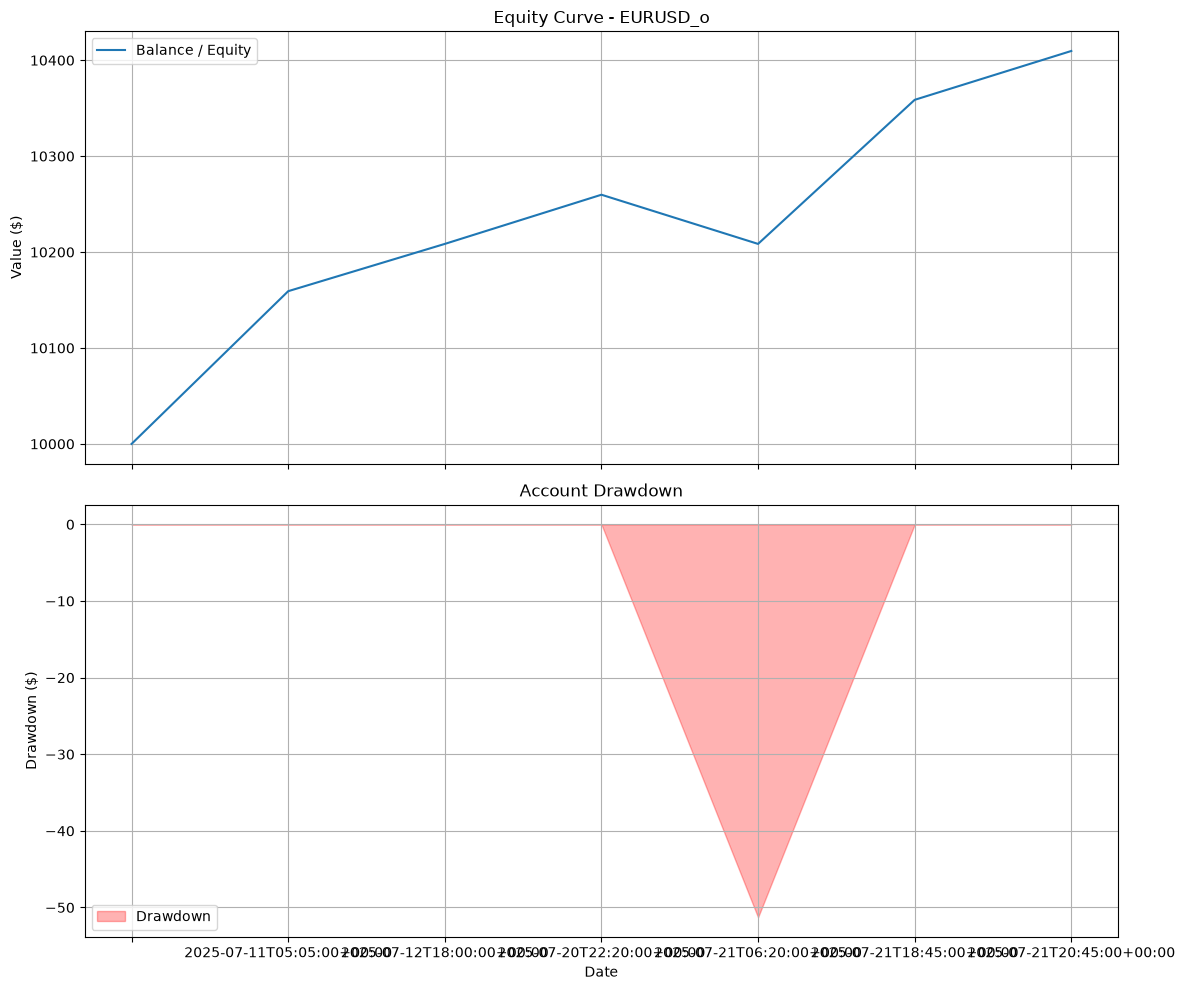

In [8]:
if lifecycles:
    df_stats = stats.df.sort_values('outcome_exit_timestamp')
    df_stats['cum_profit'] = df_stats['outcome_realized_profit'].cumsum()
    df_stats['balance'] = INITIAL_BALANCE + df_stats['cum_profit']
    
    # Calculate Drawdown
    df_stats['peak'] = df_stats['balance'].cummax()
    df_stats['drawdown'] = (df_stats['balance'] - df_stats['peak'])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Balance and Equity Plot
    ax1.plot(df_stats['outcome_exit_timestamp'], df_stats['balance'], label='Balance / Equity')
    ax1.set_title(f'Equity Curve - {SYMBOL}')
    ax1.set_ylabel('Value ($)')
    ax1.legend()
    ax1.grid(True)
    
    # Drawdown Plot
    ax2.fill_between(df_stats['outcome_exit_timestamp'], df_stats['drawdown'], 0, color='red', alpha=0.3, label='Drawdown')
    ax2.set_title('Account Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown ($)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data to plot equity curve.")

# Section 10: Position Analysis

Here we dig into the details of individual trades to identify patterns in winners and losers, including R-multiple analysis and maximum adverse excursions.

In [9]:
if not stats.df.empty:
    print("Top 10 Winners:")
    display(stats.df.nlargest(10, 'outcome_realized_profit')[['execution_ticket', 'outcome_realized_profit', 'outcome_duration']])
    
    print("\nTop 10 Losers:")
    display(stats.df.nsmallest(10, 'outcome_realized_profit')[['execution_ticket', 'outcome_realized_profit', 'outcome_duration']])
    
    longest_trade = stats.df.loc[stats.df['outcome_duration'].idxmax()]
    print(f"\nLongest Trade: Ticket {longest_trade['execution_ticket']} (Duration: {longest_trade['outcome_duration']:.0f}s)")
    
    # MAE is stored in management_maximum_adverse_excursion (as points/dollars depending on reconstruction)
    if 'management_maximum_adverse_excursion' in stats.df.columns:
        largest_mae_trade = stats.df.loc[stats.df['management_maximum_adverse_excursion'].idxmax()]
        print(f"Largest Drawdown Trade (MAE): Ticket {largest_mae_trade['execution_ticket']} (MAE: {largest_mae_trade['management_maximum_adverse_excursion']:.2f})")
    
    if 'outcome_r_multiple' in stats.df.columns:
        print(f"Best R Multiple: {stats.df['outcome_r_multiple'].max():.2f}")
        print(f"Worst R Multiple: {stats.df['outcome_r_multiple'].min():.2f}")

Top 10 Winners:


,execution_ticket,outcome_realized_profit,outcome_duration
77,1000000,159.224565,0.0
12,1000007,150.204239,0.0
87,1000010,51.276582,0.0
20,1000017,50.937555,0.0
3,1000004,49.283839,0.0
0,0,0.000000,0.0
1,0,0.000000,0.0
2,0,0.000000,0.0
4,0,0.000000,0.0
5,0,0.000000,0.0



Top 10 Losers:


,execution_ticket,outcome_realized_profit,outcome_duration
89,1000013,-51.279886,0.0
0,0,0.000000,0.0
1,0,0.000000,0.0
2,0,0.000000,0.0
4,0,0.000000,0.0
5,0,0.000000,0.0
6,0,0.000000,0.0
7,0,0.000000,0.0
8,0,0.000000,0.0
9,0,0.000000,0.0



Longest Trade: Ticket 0 (Duration: 0s)
Largest Drawdown Trade (MAE): Ticket 0 (MAE: 0.00)
Best R Multiple: 0.00
Worst R Multiple: 0.00


# Section 11: TradeAuditor Example

The `TradeAuditor` is a forensic tool that reconstructs the complete lifecycle of a single trade. It is invaluable for debugging why a specific trade succeeded or failed.

In [10]:
if not stats.df.empty:
    best_ticket = int(stats.df.nlargest(1, 'outcome_realized_profit').iloc[0]['execution_ticket'])
    worst_ticket = int(stats.df.nsmallest(1, 'outcome_realized_profit').iloc[0]['execution_ticket'])
    
    print(f"--- Forensic Audit: Best Trade (Ticket {best_ticket}) ---")
    lc_best = auditor.reconstruct_trade_lifecycle(ticket=best_ticket)
    if lc_best: print(auditor.format_report_markdown(lc_best))
    
    print(f"\n--- Forensic Audit: Worst Trade (Ticket {worst_ticket}) ---")
    lc_worst = auditor.reconstruct_trade_lifecycle(ticket=worst_ticket)
    if lc_worst: print(auditor.format_report_markdown(lc_worst))

--- Forensic Audit: Best Trade (Ticket 1000000) ---
# Position Lifecycle - Ticket 1000000
**Signal ID:** `ace595fb-d196-45f6-9dcc-596999063187`
**Status:** completed

## 1. Signal Information
- **signal_id:** ace595fb-d196-45f6-9dcc-596999063187
- **strategy:** mm
- **signal_category:** standard
- **exit_profile:** standard
- **symbol:** EURUSD_o
- **timeframe:** M5
- **direction:** -1
- **signal_timestamp:** 2026-07-08T06:41:22.165935+00:00
- **bar_timestamp:** 2025-07-10 19:50:00+00:00
- **indicator_snapshot:** {}
- **market_snapshot:** {}

## 2. Execution Information
- **ticket:** 1000000
- **magic_number:** 100002
- **requested_entry:** 1.0969488844807107
- **actual_entry:** 1.0969488844807107
- **average_entry:** 1.0969488844807107
- **initial_volume:** 1.86
- **remaining_volume:** 0.0
- **risk_percent:** 0.0099989239336839
- **risk_amount:** 0.0
- **initial_stop_loss:** 1.097486461036285
- **initial_take_profit:** 1.095873731369562
- **spread:** 0.0
- **slippage:** 0.0
- **execut

# Section 12: Journal Inspection

We inspect the raw `PositionLifecycle` records saved in the journal. These records serve as the permanent, immutable history of the strategy's activity.

In [11]:
if not stats.df.empty:
    print("Journal Record Samples:")
    display(stats.df.head(2))
    display(stats.df.tail(2))
    
    print("\nAvailable Columns:")
    print(stats.df.columns.tolist())
    
    print("\nEvent Counts:")
    journal_df = auditor.load_journal_data()
    if not journal_df.empty:
        print(journal_df['event_type'].value_counts())

Journal Record Samples:


,signal_signal_id,signal_strategy,signal_signal_category,signal_exit_profile,signal_symbol,signal_timeframe,signal_direction,signal_signal_timestamp,signal_bar_timestamp,signal_indicator_snapshot,...,outcome_profit_pips,outcome_profit_percent,outcome_r_multiple,outcome_result,outcome_strategy_reason,outcome_broker_reason,outcome_deal_count,outcome_partial_close_count,outcome_duration,outcome_status
0,c806bc14-3de8-4126-8170-a27381eb6468,mm,standard,standard,EURUSD_o,M15,-1,2026-07-08T06:41:37.545797+00:00,2025-07-19 17:30:00+00:00,{},...,0.0,0.0,0.0,open,,,0,0,0.0,open
1,18b2b5e2-d441-4354-a24c-fb720100671d,mm,high_risk,single,EURUSD_o,M15,-1,2026-07-08T06:41:38.282023+00:00,2025-07-19 21:00:00+00:00,{},...,0.0,0.0,0.0,open,,,0,0,0.0,open


,signal_signal_id,signal_strategy,signal_signal_category,signal_exit_profile,signal_symbol,signal_timeframe,signal_direction,signal_signal_timestamp,signal_bar_timestamp,signal_indicator_snapshot,...,outcome_profit_pips,outcome_profit_percent,outcome_r_multiple,outcome_result,outcome_strategy_reason,outcome_broker_reason,outcome_deal_count,outcome_partial_close_count,outcome_duration,outcome_status
188,66cd5168-9edd-4501-b55d-d7715422605f,mm,high_risk,single,EURUSD_o,M5,1,2026-07-08T06:58:34.341008+00:00,2026-07-02 08:50:00+00:00,{},...,0.0,0.0,0.0,open,,,0,0,0.0,open
189,57545aef-80bc-4c74-b9c7-96c2a84f192b,mm,high_risk,single,EURUSD_o,M5,1,2026-07-08T07:02:15.837517+00:00,2026-07-02 08:50:00+00:00,{},...,0.0,0.0,0.0,open,,,0,0,0.0,open



Available Columns:
['signal_signal_id', 'signal_strategy', 'signal_signal_category', 'signal_exit_profile', 'signal_symbol', 'signal_timeframe', 'signal_direction', 'signal_signal_timestamp', 'signal_bar_timestamp', 'signal_indicator_snapshot', 'signal_market_snapshot', 'execution_ticket', 'execution_magic_number', 'execution_requested_entry', 'execution_actual_entry', 'execution_average_entry', 'execution_initial_volume', 'execution_remaining_volume', 'execution_risk_percent', 'execution_risk_amount', 'execution_initial_stop_loss', 'execution_initial_take_profit', 'execution_spread', 'execution_slippage', 'execution_execution_latency', 'execution_broker_order_ids', 'execution_broker_deal_ids', 'management_partial_closes', 'management_breakeven_events', 'management_trailing_events', 'management_stop_loss_modifications', 'management_take_profit_modifications', 'management_maximum_favorable_excursion', 'management_maximum_adverse_excursion', 'management_highest_profit', 'management_lowe

event_type
signal             190
order_open           7
position_closed      6
partial_close        2
sl_modified          2
Name: count, dtype: int64


# Section 13: Export

Finally, we save all generated reports and statistics to the result directory for future reference.

Results exported to /app/Backtest_Results/


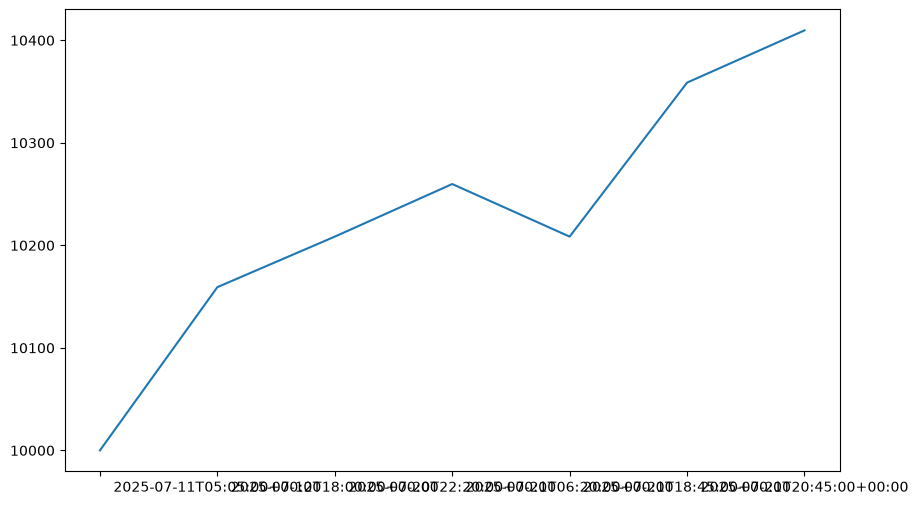

In [12]:
if not stats.df.empty:
    os.makedirs(RESULT_DIRECTORY, exist_ok=True)
    stats.df.to_csv(os.path.join(RESULT_DIRECTORY, "full_trade_history.csv"), index=False)
    
    with open(os.path.join(RESULT_DIRECTORY, "metrics_summary.json"), "w") as f:
        import json
        json.dump(metrics, f, indent=4)
        
    plt.figure(figsize=(10, 6))
    plt.plot(df_stats['outcome_exit_timestamp'], df_stats['balance'])
    plt.savefig(os.path.join(RESULT_DIRECTORY, "equity_curve.png"))
    
    print(f"Results exported to {RESULT_DIRECTORY}/")

# Section 14: Conclusions

The simulation run is complete. Below we summarize the execution and provide next steps for further analysis.

In [13]:
if 'lifecycles' in locals():
    print("Simulation completed successfully")
    print(f"Execution time: {simulation_duration:.2f}s")
    print(f"Total trades: {len(lifecycles)}")
    print(f"Location of reports: {RESULT_DIRECTORY}/")
    
    print("\nSuggested next analyses:")
    print("1. Parameter Optimization: Try changing the EMA periods in MMStrategy to see how they impact the Win Rate.")
    print("2. Different Symbols: Run this notebook again for GBPUSD_o (after downloading its data).")
    print("3. Walk-Forward Analysis: Segment the historical data into 'In-Sample' for training and 'Out-of-Sample' for validation.")

Simulation completed successfully
Execution time: 188.93s
Total trades: 190
Location of reports: /app/Backtest_Results/

Suggested next analyses:
1. Parameter Optimization: Try changing the EMA periods in MMStrategy to see how they impact the Win Rate.
2. Different Symbols: Run this notebook again for GBPUSD_o (after downloading its data).
3. Walk-Forward Analysis: Segment the historical data into 'In-Sample' for training and 'Out-of-Sample' for validation.
